## Домашнее задание 1. Обучение базовых моделей

**Сдача домашнего задания 1:**
* Назовите файл по шаблону task1_Ivanov_Ivan.ipynb, подставив свою фамилию и имя. Выполненную работу нужно отправить на почту ivan.s.zlobin@gmail.com **вместе с использовавшимся environment.yml для воспроизведения среды**, указав в теме письма "Статистические методы анализа научных данных, Иванов Иван, 4 курс", подставив свою фамилию, имя и номер курса
 **Работы, присланные иным способом, не принимаются.**
* Прислать нужно **ноутбук в формате `ipynb`**.
* Для выполнения задания **используйте этот ноутбук в качестве основы, ничего не удаляя из него**. Можно добавлять необходимое количество ячеек.
* Комментарии к решению пишите в markdown-ячейках.
* **Код из рассказанных на занятиях ноутбуков** (и из интернета, без злоупотреблений) можно использовать без ограничений.

**Дедлайн по заданию**: 23:59 15 ноября 2025 года

**Работы, присланные после дедлайна, не проверяются.**

---

**Баллы за задание:**

* Задача 1 &mdash; 2 балла
* Задача 2 &mdash; 4 балла
* Задача 3 &mdash; 2 балла
* Задача 4 &mdash; 2 балла

Оценка за задание = Сумма баллов (max 10)

---

**Проверка задания**

При частичном решении задачи за неё может быть выставлен неполный балл с шагом в 0.5 балла. 

---

In [584]:
# Импорты
import pandas as pd
import numpy as np
from tqdm.notebook import tqdm

import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="darkgrid", font_scale=1.3, palette=['#7570b3','#e7298a','#66a61e','#1b9e77','#e6ab02','#d95f02'])

from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV

from category_encoders import TargetEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.metrics import r2_score, mean_absolute_percentage_error, mean_absolute_error, mean_squared_error
from sklearn.metrics import make_scorer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestClassifier


from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

RANDOM_STATE = 42
N_JOBS = 8

In [547]:
# Загрузка данных
df = pd.read_csv('kaggle_with_decriptors.csv')

# Исходные столбцы
original_columns = {'id', 'SMILES', 'Tg', 'FFV', 'Tc', 'Density', 'Rg'}

### Задача 1: Исследование базы данных и предварительный отбор признаков (2 балла)
Загрузите датасет kaggle_with_decriptors.csv. Убедитесь, что он содержит исходные столбцы: 'id', 'SMILES', 'Tg', 'FFV', 'Tc', 'Density', 'Rg', а также дополнительные дескрипторы молекул.
Проведите предварительный анализ данных:
 - Проверьте наличие пропущенных значений.
 - Выберите два любых целевых свойства из списка Tg, Tc, Density, FFV, Rg (Далее оба выбранных вами признака будем называть y_1 и y_2)
 - Оцените распределения целевых переменных y_1 и y_2 (постройте гистограммы + проведите любой дополнительный анализ, который вам известен).
 - Определите корреляции между признаками и целевыми переменными (например, с помощью heatmap).

На основе анализа отберите подмножество признаков для дальнейшего моделирования:
 - Удалите признаки с высокой корреляцией (>0.95) между собой (оставьте один из пары).
 - Удалите признаки с низкой дисперсией (например, если стандартное отклонение < 0.01).
 - Обоснуйте свой выбор в markdown-ячейке.

In [248]:
df.shape

(7973, 132)

In [249]:
df.head()

,id,SMILES,Tg,FFV,Tc,Density,Rg,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,...,NumHAcceptors,NumHDonors,NumHeteroatoms,NumRotatableBonds,NumSaturatedCarbocycles,NumSaturatedHeterocycles,NumSaturatedRings,RingCount,MolLogP,MolMR
0,87817,*CC(*)c1ccccc1C(=O)OCCCCCC,NaN,0.374645,0.205667,NaN,NaN,13.156152,13.156152,0.826911,...,2,0,4,9,0,0,0,1,3.98170,68.4145
1,106919,*Nc1ccc([C@H](CCC)c2ccc(C3(c4ccc([C@@H](CCC)c5...,NaN,0.370410,NaN,NaN,NaN,10.076805,10.076805,0.391251,...,2,2,4,19,1,0,1,5,12.35960,193.3954
2,388772,*Oc1ccc(S(=O)(=O)c2ccc(Oc3ccc(C4(c5ccc(Oc6ccc(...,NaN,0.378860,NaN,NaN,NaN,14.843017,14.843017,0.045055,...,9,0,13,15,2,0,2,10,14.21700,281.6006
3,519416,*Nc1ccc(-c2c(-c3ccc(C)cc3)c(-c3ccc(C)cc3)c(N*)...,NaN,0.387324,NaN,NaN,NaN,9.640234,9.640234,0.441529,...,2,2,4,11,0,0,0,6,11.00768,179.8154
4,539187,*Oc1ccc(OC(=O)c2cc(OCCCCCCCCCOCC3CCCN3c3ccc([N...,NaN,0.355470,NaN,NaN,NaN,14.950467,14.950467,0.892251,...,14,0,18,34,0,2,2,6,11.84500,266.9958


In [272]:
print(*df.isna().sum())

0 0 7462 943 7236 7360 7359 0 0 0 0 0 0 0 0 0 0 0 7513 7513 7513 7513 0 0 0 7973 7973 7973 7973 7973 7973 7973 7973 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0


In [548]:
#Дропнем колонки с большик количеством NA, полученные RDkitом 
mask = df.isna().sum() > 7500
df = df.loc[:, ~mask]

In [549]:
y1, y2 = df.loc[:, 'Tg'], df.loc[:, 'Tc']
smiles = df['SMILES']
df = df.drop(['id', 'SMILES'], axis=1)

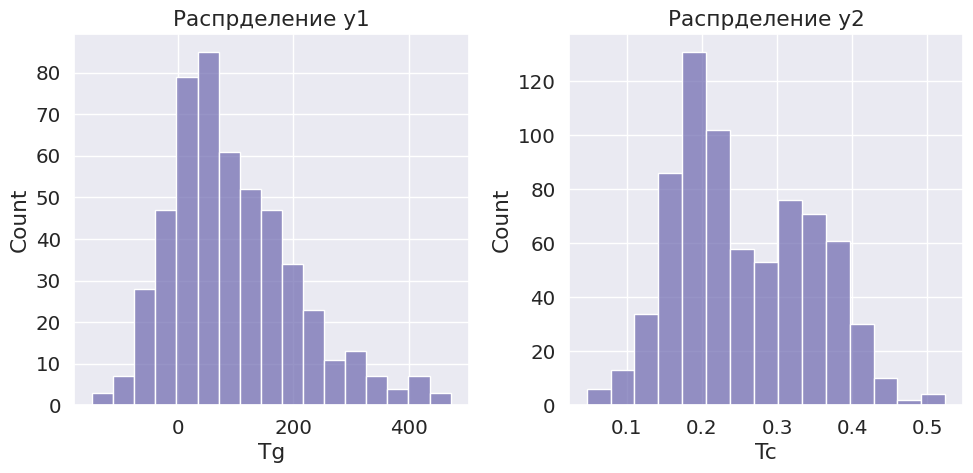

In [265]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.histplot(y1)
plt.title('Распрделение y1')
plt.subplot(1, 2, 2)
sns.histplot(y2)
plt.title('Распрделение y2')
plt.tight_layout()
plt.show()

Видим, что Tg имеет распрделение похожее на нормальное. Распрделение Tc бимодальное

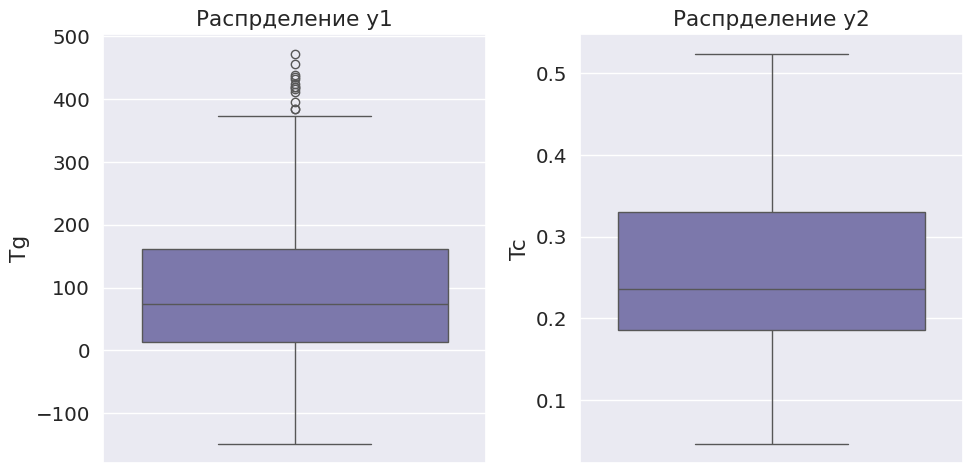

In [266]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.boxplot(y1)
plt.title('Распрделение y1')
plt.subplot(1, 2, 2)
sns.boxplot(y2)
plt.title('Распрделение y2')
plt.tight_layout()
plt.show()

Tg имеет выбросы

In [267]:
#Посмотрим на типы данных
print(df.dtypes, '\n')
print((df.dtypes == 'object'), '\n')
print((df.dtypes == 'object').sum())

FFV                         float64
Density                     float64
Rg                          float64
MaxAbsEStateIndex           float64
MaxEStateIndex              float64
                             ...   
NumSaturatedHeterocycles      int64
NumSaturatedRings             int64
RingCount                     int64
MolLogP                     float64
MolMR                       float64
Length: 116, dtype: object 

FFV                         False
Density                     False
Rg                          False
MaxAbsEStateIndex           False
MaxEStateIndex              False
                            ...  
NumSaturatedHeterocycles    False
NumSaturatedRings           False
RingCount                   False
MolLogP                     False
MolMR                       False
Length: 116, dtype: bool 

0


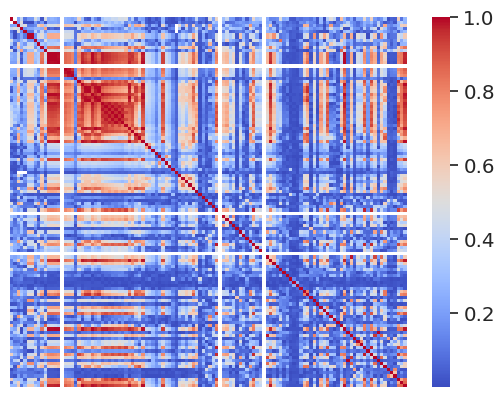

In [494]:
corr = np.abs(df.corr('spearman'))
sns.heatmap(corr, cmap='coolwarm')
plt.axis('off')
plt.show()

Видим, что множество признаков сильно скоррелированы

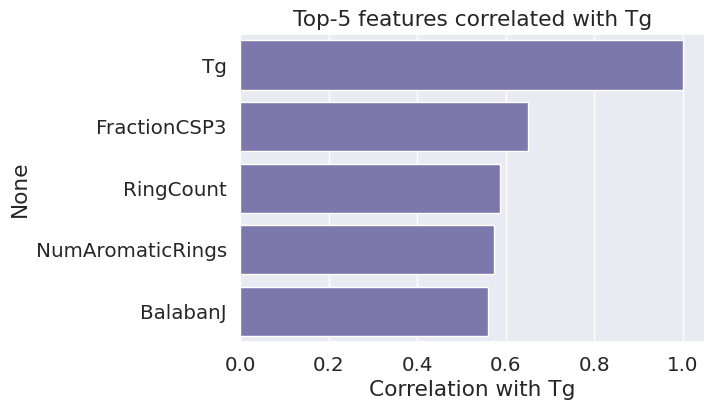

In [276]:
corr_Tg = corr['Tg'].dropna()
top5_idx = np.argsort(corr_Tg.values)[::-1][:5]
features = corr_Tg.index[top5_idx]
values = np.abs(corr_Tg.values[top5_idx])

plt.figure(figsize=(6,4))
sns.barplot(x=values, y=features)
plt.xlabel('Correlation with Tg')
plt.title('Top-5 features correlated with Tg')
plt.show()

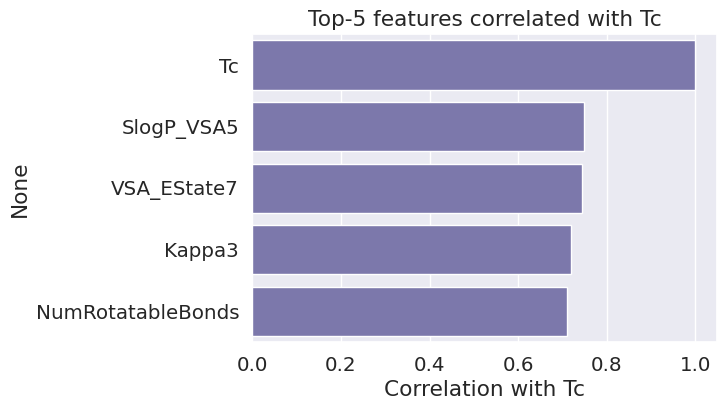

In [277]:
corr_Tg = corr['Tc'].dropna()
top5_idx = np.argsort(corr_Tg.values)[::-1][:5]
features = corr_Tg.index[top5_idx]
values = np.abs(corr_Tg.values[top5_idx])

plt.figure(figsize=(6,4))
sns.barplot(x=values, y=features)
plt.xlabel('Correlation with Tc')
plt.title('Top-5 features correlated with Tc')
plt.show()

In [550]:
df = df.drop(['Tg', 'Tc'], axis=1)

In [551]:
corr_matrix = df.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]
df = df.drop(columns=to_drop)
print(f"Удалено {len(to_drop)} признаков:")
print(*to_drop)

Удалено 29 признаков:
MaxEStateIndex HeavyAtomMolWt ExactMolWt NumValenceElectrons FpDensityMorgan2 FpDensityMorgan3 BertzCT Chi0n Chi0v Chi1 Chi1n Chi1v Chi2n Chi2v Chi3n Chi3v Chi4n Chi4v LabuteASA SlogP_VSA6 EState_VSA1 VSA_EState1 HeavyAtomCount NOCount NumAromaticCarbocycles NumAromaticRings NumHDonors RingCount MolMR


In [552]:
to_drop = [column for column in df.columns if np.nanstd(df[column].values, ddof=1) < 0.01]
df = df.drop(columns=to_drop)
print(f"Удалено {len(to_drop)} признаков:")
print(*to_drop)

Удалено 3 признаков:
NumRadicalElectrons SMR_VSA8 SlogP_VSA9


In [508]:
print("Any +inf:", np.isposinf(X_train.select_dtypes(include=[np.number])).any().any())
print("Any -inf:", np.isneginf(X_train.select_dtypes(include=[np.number])).any().any())

num = X_train.select_dtypes(include=[np.number])
inf_cols = num.columns[np.isinf(num).any(axis=0)]
print("Columns with inf:", list(inf_cols))

# Максимальные по модулю значения
print((num.abs().max()).sort_values(ascending=False).head(10))

Any +inf: False
Any -inf: False
Columns with inf: []
Ipc            4.839989e+97
MolWt          1.449546e+03
SlogP_VSA5     6.094174e+02
PEOE_VSA14     5.561090e+02
SMR_VSA5       4.227768e+02
SlogP_VSA2     3.845434e+02
SMR_VSA7       3.677058e+02
VSA_EState7    3.426817e+02
SMR_VSA6       3.036292e+02
PEOE_VSA6      2.950704e+02
dtype: float64


In [553]:
#Убёрем такие Ipc, модели ругаются
df = df.drop(['Ipc'], axis=1)

In [554]:
data = df.copy()
print(data.shape)
data.head()

(7973, 83)


,FFV,Density,Rg,MaxAbsEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,FpDensityMorgan1,...,NumAliphaticHeterocycles,NumAliphaticRings,NumAromaticHeterocycles,NumHAcceptors,NumHeteroatoms,NumRotatableBonds,NumSaturatedCarbocycles,NumSaturatedHeterocycles,NumSaturatedRings,MolLogP
0,0.374645,NaN,NaN,13.156152,0.826911,-4.347323,0.500278,38.588235,232.323,1.705882,...,0,0,0,2,4,9,0,0,0,3.98170
1,0.370410,NaN,NaN,10.076805,0.391251,-5.705407,0.125364,44.177778,598.919,0.755556,...,0,1,0,2,4,19,1,0,1,12.35960
2,0.378860,NaN,NaN,14.843017,0.045055,-6.132486,0.092387,31.863014,1003.207,0.452055,...,0,2,0,9,13,15,2,0,2,14.21700
3,0.387324,NaN,NaN,9.640234,0.441529,-3.471859,0.209590,24.285714,542.726,0.428571,...,0,0,0,2,4,11,0,0,0,11.00768
4,0.355470,NaN,NaN,14.950467,0.892251,-5.643625,0.014164,40.628571,965.154,0.628571,...,2,2,0,14,18,34,0,2,2,11.84500


In [512]:
data.isna().sum()

FFV                          943
Density                     7360
Rg                          7359
MaxAbsEStateIndex              0
MinAbsEStateIndex              0
                            ... 
NumRotatableBonds              0
NumSaturatedCarbocycles        0
NumSaturatedHeterocycles       0
NumSaturatedRings              0
MolLogP                        0
Length: 83, dtype: int64

Много Nanов было выброшены, потому что целые столбцы состоят только из них. Убрал признаки с std < 0.01, скоррелированные на $\rho$ > 0.95, а также столбец SMILES (вся информация из него получена) и id (неинформативно). В качеству целевых выбраны y1: 'Tg', y2: 'Tc'

### Задача 2: Построение регрессионных моделей для двух целевых свойств (4 балла)

Для каждого из выбранных свойств y_1 и y_2:
 - Разделите данные на обучающую (train) и тестовую (holdout) выборки в соотношении 80/20. Убедитесь, что разбиение воспроизводимо (random_state=42).
 - Выберите несколько (2+) разных моделей регрессии (например, RandomForestRegressor, SVR, XGBoostRegressor, Ridge, KNeighborsRegressor).
 - Для каждой модели выполните подбор гиперпараметров с помощью кросс-валидации (например, GridSearchCV или optuna study) на обучающей выборке. Обоснуйте выбор метрики (MSE или MAE), используйте её как целевую функцию для оптимизации 
 - Обучите лучшую модель и оцените её качество на holdout-тесте, используя RMSE и R².
 - Сравните модели для каждого свойства и выберите лучшую по качеству на тесте.
 - Приведите таблицу с итоговыми метриками (RMSE, R²) для обеих задач и всех использованных моделей.

In [513]:
#Поищем категориальные признаки
print('Количество уникальных значений признака')
for column in data.columns:
    print(f'{column}: {data[column].nunique()}')

Количество уникальных значений признака
FFV: 6995
Density: 613
Rg: 614
MaxAbsEStateIndex: 7810
MinAbsEStateIndex: 7885
MinEStateIndex: 7875
qed: 6714
SPS: 4082
MolWt: 5527
FpDensityMorgan1: 1142
AvgIpc: 7275
BalabanJ: 7435
Chi0: 4396
HallKierAlpha: 2071
Kappa1: 5508
Kappa2: 5867
Kappa3: 6456
PEOE_VSA1: 58
PEOE_VSA10: 86
PEOE_VSA11: 41
PEOE_VSA12: 34
PEOE_VSA13: 20
PEOE_VSA14: 6025
PEOE_VSA2: 37
PEOE_VSA3: 27
PEOE_VSA4: 40
PEOE_VSA5: 12
PEOE_VSA6: 232
PEOE_VSA7: 320
PEOE_VSA8: 360
PEOE_VSA9: 426
SMR_VSA1: 3669
SMR_VSA10: 1541
SMR_VSA2: 24
SMR_VSA3: 127
SMR_VSA4: 79
SMR_VSA5: 1663
SMR_VSA6: 403
SMR_VSA7: 1363
SMR_VSA9: 313
SlogP_VSA1: 502
SlogP_VSA10: 162
SlogP_VSA11: 27
SlogP_VSA12: 98
SlogP_VSA2: 1825
SlogP_VSA3: 492
SlogP_VSA4: 133
SlogP_VSA5: 3471
SlogP_VSA7: 152
SlogP_VSA8: 335
TPSA: 1106
EState_VSA10: 629
EState_VSA11: 43
EState_VSA2: 805
EState_VSA3: 142
EState_VSA4: 63
EState_VSA5: 30
EState_VSA6: 19
EState_VSA7: 14
EState_VSA8: 246
EState_VSA9: 1670
VSA_EState10: 784
VSA_EState2

In [514]:
cat_cols = [
    "NHOHCount",
    "NumAliphaticCarbocycles",
    "NumAliphaticHeterocycles",
    "NumAliphaticRings",
    "NumAromaticHeterocycles",
    "NumHAcceptors",
    "NumHeteroatoms",
    "NumRotatableBonds",
    "NumSaturatedCarbocycles",
    "NumSaturatedHeterocycles",
    "NumSaturatedRings"
]
num_cols = data.columns.difference(cat_cols)
metrics = [mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score]

## y1: 'Tg'

### XGBoost

In [558]:
mask = y1.isna()
X = data.loc[~mask, :]
X_train, X_test, y_train, y_test = train_test_split(X, y1[~mask], test_size=0.2, random_state=RANDOM_STATE)

In [559]:
X.shape

(511, 83)

In [560]:
X.isna().sum()

FFV                         510
Density                     487
Rg                          487
MaxAbsEStateIndex             0
MinAbsEStateIndex             0
                           ... 
NumRotatableBonds             0
NumSaturatedCarbocycles       0
NumSaturatedHeterocycles      0
NumSaturatedRings             0
MolLogP                       0
Length: 83, dtype: int64

In [524]:
%%time

X_train.loc[:, cat_cols] = X_train.loc[:, cat_cols].astype('category')
X_test.loc[:, cat_cols] = X_test.loc[:, cat_cols].astype('category')

model = RandomizedSearchCV(
    estimator=XGBRegressor(random_state=RANDOM_STATE, enable_categorical=True),
    param_distributions={
        'max_depth': np.arange(3, 8),
        'n_estimators': np.arange(10, 200),
        'learning_rate': np.linspace(0.05, 0.3, 300)
    },
    cv=5,
    scoring='r2',
    verbose=1,
    n_iter=100,
    random_state=RANDOM_STATE,
    n_jobs = -1
)

model.fit(X_train, y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits
CPU times: user 2.25 s, sys: 149 ms, total: 2.4 s
Wall time: 59.6 s


,estimator,"XGBRegressor(...ree=None, ...)"
,param_distributions,"{'learning_rate': array([0.05 ..., 0.3 ]), 'max_depth': array([3, 4, 5, 6, 7]), 'n_estimators': array([ 10, ...97, 198, 199])}"
,n_iter,100
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [526]:
y_pred = model.predict(X_test)
for metric in metrics:
    print(f'{' '.join(str(metric).split()[1].split('_'))}: {metric(y_test, y_pred):.2f}')

mean squared error: 4709.30
mean absolute error: 56.05
mean absolute percentage error: 2.26
r2 score: 0.51


### Ridge

In [527]:
#Удалим, так как в интересубщем датасете только одно значение
X = X.drop(['FFV'], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y1[~mask], test_size=0.2, random_state=RANDOM_STATE)
#Почему то работает только так
for col in cat_cols:
    X_train[col] = X_train[col].astype('category')
    X_test[col] = X_test[col].astype('category')

In [528]:
imp = IterativeImputer(estimator=RandomForestRegressor(n_estimators=10), max_iter=3, random_state=RANDOM_STATE)
scaler = StandardScaler()
enc = TargetEncoder(smoothing=0.3)

cat_cols = [
    "NHOHCount",
    "NumAliphaticCarbocycles",
    "NumAliphaticHeterocycles",
    "NumAliphaticRings",
    "NumAromaticHeterocycles",
    "NumHAcceptors",
    "NumHeteroatoms",
    "NumRotatableBonds",
    "NumSaturatedCarbocycles",
    "NumSaturatedHeterocycles",
    "NumSaturatedRings"
]
num_cols = X.columns.difference(cat_cols)

num_pipeline = Pipeline([
    ('imp', imp),
    ('scaler', scaler)
])
cat_pipeline = Pipeline([
    ('enc', enc)
])
transformer = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

In [530]:
res = []
#Предварительно посмотрел примерные значения
alpha_grid = np.linspace(10, 50, 10)
for alpha in tqdm(alpha_grid):
    
    model = Pipeline([
        ('transformer', transformer),
        ('model', Ridge(alpha=alpha))
    ])
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    print(f'alpha = {alpha}:')
    for metric in metrics:
        print(f'{' '.join(str(metric).split()[1].split('_'))}: {metric(y_test, y_pred):.2f}')
    print()
    res.append(r2_score(y_test, y_pred))

alpha = 10.0:
mean squared error: 5453.01
mean absolute error: 56.77
mean absolute percentage error: 1.89
r2 score: 0.43

alpha = 14.444444444444445:
mean squared error: 5387.28
mean absolute error: 56.55
mean absolute percentage error: 1.84
r2 score: 0.44

alpha = 18.88888888888889:
mean squared error: 5382.09
mean absolute error: 55.86
mean absolute percentage error: 1.85
r2 score: 0.44

alpha = 23.333333333333336:
mean squared error: 5429.74
mean absolute error: 56.24
mean absolute percentage error: 1.92
r2 score: 0.43

alpha = 27.77777777777778:
mean squared error: 5481.38
mean absolute error: 56.29
mean absolute percentage error: 1.90
r2 score: 0.43

alpha = 32.22222222222222:
mean squared error: 5570.48
mean absolute error: 57.03
mean absolute percentage error: 2.00
r2 score: 0.42

alpha = 36.66666666666667:
mean squared error: 5556.71
mean absolute error: 56.89
mean absolute percentage error: 2.02
r2 score: 0.42

alpha = 41.111111111111114:
mean squared error: 5496.94
mean absol

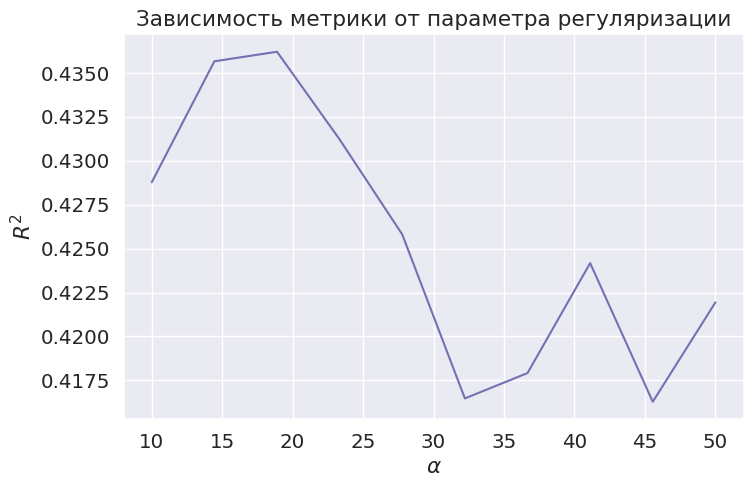

In [534]:
plt.figure(figsize=(8, 5))
plt.plot(alpha_grid, res)
plt.xlabel(r'$\alpha$')
plt.ylabel(r'$R^2$')
plt.title('Зависимость метрики от параметра регуляризации')
plt.show()

### SVR

In [532]:
%%time

param_distributions = {
    'model__C': np.linspace(1, 50, 50),
    'model__epsilon': np.linspace(0.01, 1.0, 50),
    'model__kernel': ['rbf', 'linear', 'poly'] 
}

model = Pipeline([
    ('transformer', transformer),
    ('model', SVR())
])
model = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_distributions,
    n_iter=10,                 
    cv=5,                    
    random_state=42,
    n_jobs=N_JOBS
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
for metric in metrics:
    name = ' '.join(str(metric).split()[1].split('_'))
    print(f'{name}: {metric(y_test, y_pred):.2f}')
#Дефолтная оптимизация по r2

mean squared error: 5438.69
mean absolute error: 54.96
mean absolute percentage error: 2.11
r2 score: 0.43
CPU times: user 46.1 s, sys: 2.09 s, total: 48.2 s
Wall time: 4min


С точки зрения r2_score лучшим оказался бустинг

## y2: 'Tc'

Построим только бустинг, как лучшую модель из предыдущего пункта

In [615]:
mask = y2.isna()
X = data.loc[~mask, :]
X_train, X_test, y_train, y_test = train_test_split(X, y2[~mask], test_size=0.2, random_state=RANDOM_STATE)

In [616]:
%%time

X_train.loc[:, cat_cols] = X_train.loc[:, cat_cols].astype('category')
X_test.loc[:, cat_cols] = X_test.loc[:, cat_cols].astype('category')

model = RandomizedSearchCV(
    estimator=XGBRegressor(random_state=RANDOM_STATE, enable_categorical=True),
    param_distributions={
        'max_depth': np.arange(3, 8),
        'n_estimators': np.arange(10, 200),
        'learning_rate': np.linspace(0.05, 0.3, 300)
    },
    cv=5,
    scoring='r2',
    verbose=1,
    n_iter=100,
    random_state=RANDOM_STATE,
    n_jobs = -1
)

model.fit(X_train, y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits
CPU times: user 3.17 s, sys: 155 ms, total: 3.32 s
Wall time: 45.6 s


,estimator,"XGBRegressor(...ree=None, ...)"
,param_distributions,"{'learning_rate': array([0.05 ..., 0.3 ]), 'max_depth': array([3, 4, 5, 6, 7]), 'n_estimators': array([ 10, ...97, 198, 199])}"
,n_iter,100
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [617]:
y_pred = model.predict(X_test)
for metric in metrics:
    print(f'{' '.join(str(metric).split()[1].split('_'))}: {metric(y_test, y_pred):.2f}')

mean squared error: 0.00
mean absolute error: 0.03
mean absolute percentage error: 0.13
r2 score: 0.78


## Задача 3: Преобразование регрессии в задачу классификации (2 балла)

Преобразуйте задачу регрессии в бинарную классификацию, например:

Класс 1: y_1 > median(y_1), y_2 > median(y_2)

Класс 0: y_1 ≤ median(y_1) | y_2 ≤ median(y_2)

Постройте модель классификации:
 - Используйте тот же набор признаков, что и в задаче 2.
 - Разбейте данные на train/holdout (с тем же random_state=42, чтобы разбиение совпадало с задачей 2).
 - Подберите гиперпараметры с помощью кросс-валидации (например, GridSearchCV или optuna с метрикой f1).
 - Оцените финальную модель на holdout-выборке: выведите accuracy, precision, recall, F1-score и confusion matrix.

In [649]:
y_cl = (y1 > y1.median()) * (y2 > y2.median())
y_cl.sum()

np.int64(3)

Классы очень несбалансированы, потому что много Nan и они не в совпадающих местах. Скорее всего, модели будут просто предсказывать 0 везде и получать очень высокое качество. По хорошему, нужно разбивать на выборки стратифицировано, давать веса в лоссе и смотреть метрику precision

In [633]:
X_train, X_test, y_train, y_test = train_test_split(data, y_cl, test_size=0.2, random_state=RANDOM_STATE, stratify=y_cl)

In [577]:
%%time
#Не буду подбирать гиперпараметры, и так достаточно долго. Технику подроба см. выше

for col in cat_cols:
    X_train[col] = X_train[col].astype('category')
    X_test[col] = X_test[col].astype('category')
model = Pipeline([
    ('transformer', transformer),
    ('model', RandomForestClassifier(class_weight='balanced', random_state=42))
])

model.fit(X_train, y_train)

CPU times: user 6min 53s, sys: 130 ms, total: 6min 53s
Wall time: 6min 53s


,steps,"[('transformer', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [589]:
metrics = [accuracy_score, precision_score, recall_score, f1_score]

y_pred = model.predict(X_test)
for metric in metrics:
    name = ' '.join(str(metric).split()[1].split('_'))
    print(f'{name}: {metric(y_test, y_pred):.2f}')

matrix = confusion_matrix(y_test, y_pred)

pd.DataFrame(
    matrix,
    columns=["Predict Negative", "Predict Positive"],
    index=["Actual Negative", "Actual Positive"],
)

accuracy score: 1.00
precision score: 0.00
recall score: 0.00
f1 score: 0.00


/home/kirill/miniconda3/envs/ChemMLcource/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,Predict Negative,Predict Positive
Actual Negative,1594,0
Actual Positive,1,0


Несмотря на указание веса, модель всё равно не увидела 1. Возможно, статистически данные для разных классов не сильно отличаются. Можно также пройтись по y1, y2 SimpleImputer-ом, поставить, например, медианные или средние значения в пропуски

In [609]:
med1 = y1.median()
med2 = y2.median()
y1_imp = y1.fillna(med1)
y2_imp = y2.fillna(med2)
y_cl = (y1_imp > med1) * (y2_imp > med2)
y_cl.sum()

np.int64(3)

По условию задачи всё равно не получается сделать лучше

## Задача 4: Сравнение классификации через регрессию и прямую классификацию (2 балла)
Возьмите лучшие обученные регрессионные модели из задачи 2.

- Примените их к holdout-выборке и получите предсказанные значения. Преобразуйте эти предсказания в бинарные метки по тому же порогу, что и в задаче 3. Рассчитайте f1 такой «косвенной» классификации.
- Сравните их с f1 прямой модели классификации из задачи 3.
- Сделайте вывод: какая стратегия эффективнее? Почему?

Предскажем ещё раз y1

In [643]:
%%time

mask = y1.isna()
X = data.loc[~mask, :]
X_train, X_test, y_train, y_test = train_test_split(X, y1[~mask], test_size=0.2, random_state=RANDOM_STATE)

X_train.loc[:, cat_cols] = X_train.loc[:, cat_cols].astype('category')
X_test.loc[:, cat_cols] = X_test.loc[:, cat_cols].astype('category')

model1 = RandomizedSearchCV(
    estimator=XGBRegressor(random_state=RANDOM_STATE, enable_categorical=True),
    param_distributions={
        'max_depth': np.arange(3, 8),
        'n_estimators': np.arange(10, 200),
        'learning_rate': np.linspace(0.05, 0.3, 300)
    },
    cv=5,
    scoring='r2',
    verbose=1,
    n_iter=100,
    random_state=RANDOM_STATE,
    n_jobs = -1
)

model1.fit(X_train, y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits
CPU times: user 1.91 s, sys: 137 ms, total: 2.05 s
Wall time: 55.2 s


,estimator,"XGBRegressor(...ree=None, ...)"
,param_distributions,"{'learning_rate': array([0.05 ..., 0.3 ]), 'max_depth': array([3, 4, 5, 6, 7]), 'n_estimators': array([ 10, ...97, 198, 199])}"
,n_iter,100
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [644]:
metrics = [mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score]
y_pred1 = model1.predict(X_test)
for metric in metrics:
    print(f'{' '.join(str(metric).split()[1].split('_'))}: {metric(y_test, y_pred1):.2f}')

mean squared error: 4709.30
mean absolute error: 56.05
mean absolute percentage error: 2.26
r2 score: 0.51


И y2

In [645]:
%%time

mask = y2.isna()
X = data.loc[~mask, :]
X_train, X_test, y_train, y_test = train_test_split(X, y2[~mask], test_size=0.2, random_state=RANDOM_STATE)

X_train.loc[:, cat_cols] = X_train.loc[:, cat_cols].astype('category')
X_test.loc[:, cat_cols] = X_test.loc[:, cat_cols].astype('category')

model2 = RandomizedSearchCV(
    estimator=XGBRegressor(random_state=RANDOM_STATE, enable_categorical=True),
    param_distributions={
        'max_depth': np.arange(3, 8),
        'n_estimators': np.arange(10, 200),
        'learning_rate': np.linspace(0.05, 0.3, 300)
    },
    cv=5,
    scoring='r2',
    verbose=1,
    n_iter=100,
    random_state=RANDOM_STATE,
    n_jobs = -1
)

model2.fit(X_train, y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits
CPU times: user 2.84 s, sys: 152 ms, total: 2.99 s
Wall time: 42.1 s


,estimator,"XGBRegressor(...ree=None, ...)"
,param_distributions,"{'learning_rate': array([0.05 ..., 0.3 ]), 'max_depth': array([3, 4, 5, 6, 7]), 'n_estimators': array([ 10, ...97, 198, 199])}"
,n_iter,100
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [647]:
metrics = [mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score]
y_pred2 = model2.predict(X_test)
for metric in metrics:
    print(f'{' '.join(str(metric).split()[1].split('_'))}: {metric(y_test, y_pred2):.2f}')

mean squared error: 0.00
mean absolute error: 0.03
mean absolute percentage error: 0.13
r2 score: 0.78


In [657]:
y_cl = (y1 > y1.median()) * (y2 > y2.median())
X_train, X_test, y_train, y_test = train_test_split(data, y_cl, test_size=0.2, random_state=RANDOM_STATE, stratify=y_cl)
y1_cl_reg = model1.predict(X_test) > med1
y2_cl_reg = model2.predict(X_test) > med2

In [658]:
metrics = [accuracy_score, precision_score, recall_score, f1_score]

for metric in metrics:
    name = ' '.join(str(metric).split()[1].split('_'))
    print(f'{name}: {metric(y_test, y1_cl_reg):.2f}')

matrix = confusion_matrix(y_test, y1_cl_reg)

pd.DataFrame(
    matrix,
    columns=["Predict Negative", "Predict Positive"],
    index=["Actual Negative", "Actual Positive"],
)

accuracy score: 0.39
precision score: 0.00
recall score: 0.00
f1 score: 0.00


,Predict Negative,Predict Positive
Actual Negative,626,968
Actual Positive,1,0


Тут совсем всё плохо вышло, потому что регрессионные модели по другому обрабатывали пропуски, однако я бы больше доверям именно им